In [1]:
from langgraph.graph import StateGraph, MessagesState, START,END


In [2]:
from langchain.chat_models import init_chat_model


In [3]:
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
#gemini_llm = init_chat_model(model="gpt-4o")
model_id = "gemini-2.0-flash-lite-001"
gemini_llm = init_chat_model(model=model_id, model_provider="google_vertexai")

In [5]:
class SummaryState(MessagesState):
    summary: str

In [6]:
def answer(state: SummaryState) -> SummaryState:
    state['messages'] = gemini_llm.invoke(state['messages'])
    return state

In [7]:
from langgraph.checkpoint.memory import InMemorySaver

In [8]:
graph_builder = StateGraph(SummaryState)
graph_builder.add_node("answer", answer)
graph_builder.add_edge(START, "answer")
graph_builder.add_edge("answer", END)

graph = graph_builder.compile(checkpointer=InMemorySaver())

In [9]:
from langgraph.graph.state import CompiledStateGraph
from IPython.display import Image, display

def draw_graph(graph: CompiledStateGraph):
    display(Image(graph.get_graph().draw_mermaid_png()))

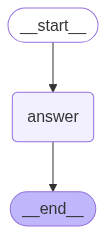

In [10]:
draw_graph(graph)


In [11]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage


In [12]:
message = [SystemMessage(content="You are an Helpful Assistant")]


In [13]:
message = [
    HumanMessage(content="Hello, how are you?")
]
result = graph.invoke({
    "messages": message
}, config={"configurable": {"thread_id": "11"}})
result

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='a2b37f1b-887d-4383-8b60-768fbef5baa1'),
  AIMessage(content="I am doing well, thank you for asking! As a large language model, I don't experience emotions, but I am functioning properly and ready to assist you. How can I help you today?\n", additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 6, 'candidates_token_count': 42, 'total_token_count': 48, 'prompt_tokens_details': [{'modality': 1, 'token_count': 6}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 42}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.08552582491011847, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--f5fc4db2-bb8e-4213-8297-7e1fc19e00c6-0', usage_metadata={'input_tokens': 6, 'output_tokens': 42, 'total_tokens': 48})]}

In [14]:
result['messages']


[HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='a2b37f1b-887d-4383-8b60-768fbef5baa1'),
 AIMessage(content="I am doing well, thank you for asking! As a large language model, I don't experience emotions, but I am functioning properly and ready to assist you. How can I help you today?\n", additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 6, 'candidates_token_count': 42, 'total_token_count': 48, 'prompt_tokens_details': [{'modality': 1, 'token_count': 6}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 42}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.08552582491011847, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--f5fc4db2-bb8e-4213-8297-7e1fc19e00c6-0', usage_metadata={'input_tokens': 6, 'output_tokens': 42, 'total_tokens': 48})]

In [15]:
message = [
    HumanMessage(content="Hello, how are you?")
]
result = graph.invoke({
    "messages": message
}, config={"configurable": {"thread_id": "11"}})

In [16]:
result['messages']


[HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='a2b37f1b-887d-4383-8b60-768fbef5baa1'),
 AIMessage(content="I am doing well, thank you for asking! As a large language model, I don't experience emotions, but I am functioning properly and ready to assist you. How can I help you today?\n", additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 6, 'candidates_token_count': 42, 'total_token_count': 48, 'prompt_tokens_details': [{'modality': 1, 'token_count': 6}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 42}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.08552582491011847, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--f5fc4db2-bb8e-4213-8297-7e1fc19e00c6-0', usage_metadata={'input_tokens': 6, 'output_tokens': 42, 'total_tokens': 48}),
 HumanMessage(content='Hello, h

In [17]:
result = graph.invoke({
    "messages": HumanMessage("when was ipl launched in india?")
}, config={"configurable":{"thread_id": "11"}})

In [18]:
result["messages"]

[HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='a2b37f1b-887d-4383-8b60-768fbef5baa1'),
 AIMessage(content="I am doing well, thank you for asking! As a large language model, I don't experience emotions, but I am functioning properly and ready to assist you. How can I help you today?\n", additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 6, 'candidates_token_count': 42, 'total_token_count': 48, 'prompt_tokens_details': [{'modality': 1, 'token_count': 6}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 42}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.08552582491011847, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--f5fc4db2-bb8e-4213-8297-7e1fc19e00c6-0', usage_metadata={'input_tokens': 6, 'output_tokens': 42, 'total_tokens': 48}),
 HumanMessage(content='Hello, h

In [19]:
result = graph.invoke({
    "messages": HumanMessage("Which cricketer got the highest bid price during launch ?")
},config={"configurable": {"thread_id": "11"}})

In [20]:
result['messages']


[HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='a2b37f1b-887d-4383-8b60-768fbef5baa1'),
 AIMessage(content="I am doing well, thank you for asking! As a large language model, I don't experience emotions, but I am functioning properly and ready to assist you. How can I help you today?\n", additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 6, 'candidates_token_count': 42, 'total_token_count': 48, 'prompt_tokens_details': [{'modality': 1, 'token_count': 6}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 42}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.08552582491011847, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--f5fc4db2-bb8e-4213-8297-7e1fc19e00c6-0', usage_metadata={'input_tokens': 6, 'output_tokens': 42, 'total_tokens': 48}),
 HumanMessage(content='Hello, h

In [21]:
response = gemini_llm.invoke(f"Can you summarize {result['messages']}")


In [22]:
response

AIMessage(content='The conversation starts with two greetings and the AI responding that it is doing well and ready to assist. The conversation then shifts to IPL-related questions:\n\n*   **Question:** When was IPL launched?\n*   **Answer:** 2008.\n*   **Question:** Who got the highest bid price during the launch?\n*   **Answer:** Mahendra Singh Dhoni for $1.5 million (Chennai Super Kings).', additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 1443, 'candidates_token_count': 90, 'total_token_count': 1533, 'prompt_tokens_details': [{'modality': 1, 'token_count': 1443}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 90}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.2971067852444119, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--e1d90bf5-3a65-42ee-88dd-32749a6fb514-0', usage_metadata={'input_tokens': 1443, 

In [24]:
#gemini_llm = init_chat_model(model="gpt-4o")


In [25]:
class SummaryState(MessagesState):
    summary: str

In [26]:
def answer(state: SummaryState) -> SummaryState:
    summary = state['summary']
    
    if summary.strip() == "":
        messages = state['messages']
    else:
        system_message = f"This is conversation of existing summary {summary}"
        messages = [SystemMessage(system_message)] + state['messages']
    state['messages'] = gemini_llm.invoke(messages)
    return state#

In [27]:
from langchain_core.messages import RemoveMessage
def summarize(state: SummaryState) -> SummaryState:
    summary = state['summary']

    if summary.strip() == "":
        pass
    else:
        if len(state['messages']) >= 6:
            system_message = SystemMessage(f"Summarize the following messsages {state['messages']}")
            result_message = gemini_llm.invoke(system_message)
            state['summary'] = result_message.content
            deleted_messages = [RemoveMessage(id = m.id) for m in state['messages'][-2:]]
            state['messages'] = deleted_messages + result_message
    return state

In [28]:
from typing import Literal
def should_summarise(state: SummaryState) -> Literal["yes", "no"]:
    if len(state['messages']) >= 6:
        return "yes"
    else:
        return "no"

In [29]:
summarize_graph_builder = StateGraph(SummaryState)
summarize_graph_builder.add_node("conversation", answer)
summarize_graph_builder.add_node("summarize_conversation", summarize)
summarize_graph_builder.set_entry_point("conversation")
summarize_graph_builder.add_conditional_edges(
   "conversation",
   should_summarise,
   {
       "yes": "summarize_conversation",
       "no": END
   }
)
summary_graph = summarize_graph_builder.compile(checkpointer=InMemorySaver())

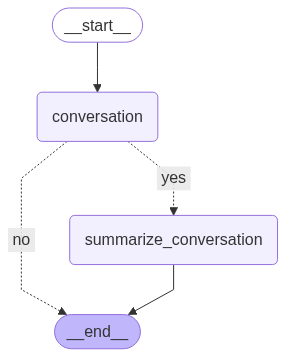

In [30]:
draw_graph(summary_graph)


In [31]:
result = summary_graph.invoke(
    { "messages": [
        SystemMessage("You are an expert Sports Author"),
        HumanMessage('What is most viewed Sport and what is the viewership?')],
        "summary": ""
    },
    config={"configurable": {"thread_id": "13"}}
)

In [32]:
result

{'messages': [SystemMessage(content='You are an expert Sports Author', additional_kwargs={}, response_metadata={}, id='1c17d6a9-e824-4d9a-a5f9-e27c1d106676'),
  HumanMessage(content='What is most viewed Sport and what is the viewership?', additional_kwargs={}, response_metadata={}, id='56758275-a1ff-46cc-8f3a-4590a06c2fdc'),
  AIMessage(content="The most-viewed sport in the world is **soccer (football)**.\n\nEstimating the global viewership of soccer is a complex task due to the decentralized nature of how matches are broadcast and watched. However, it's widely accepted that billions of people around the world follow the sport.\n\n*   **Global events like the FIFA World Cup**: These tournaments consistently attract massive viewership. The 2022 FIFA World Cup in Qatar had a cumulative viewership of **over 5 billion** viewers, according to FIFA.\n*   **Club Competitions**: Popular club competitions like the English Premier League, La Liga (Spain), Serie A (Italy), Bundesliga (Germany), a

In [33]:
for message in result['messages']:
    message.pretty_print()

================================ System Message ================================

You are an expert Sports Author
================================ Human Message =================================

What is most viewed Sport and what is the viewership?
================================== Ai Message ==================================

The most-viewed sport in the world is **soccer (football)**.

Estimating the global viewership of soccer is a complex task due to the decentralized nature of how matches are broadcast and watched. However, it's widely accepted that billions of people around the world follow the sport.

*   **Global events like the FIFA World Cup**: These tournaments consistently attract massive viewership. The 2022 FIFA World Cup in Qatar had a cumulative viewership of **over 5 billion** viewers, according to FIFA.
*   **Club Competitions**: Popular club competitions like the English Premier League, La Liga (Spain), Serie A (Italy), Bundesliga (Germany), and the UEFA Champions

In [34]:
result = summary_graph.invoke(
    { "messages": [
        HumanMessage('Who is higest paid soccer personality in history ?')],
        "summary": ""
    },
    config={"configurable": {"thread_id": "13"}}
)
for message in result['messages']:
    message.pretty_print()

================================ System Message ================================

You are an expert Sports Author
================================ Human Message =================================

What is most viewed Sport and what is the viewership?
================================== Ai Message ==================================

The most-viewed sport in the world is **soccer (football)**.

Estimating the global viewership of soccer is a complex task due to the decentralized nature of how matches are broadcast and watched. However, it's widely accepted that billions of people around the world follow the sport.

*   **Global events like the FIFA World Cup**: These tournaments consistently attract massive viewership. The 2022 FIFA World Cup in Qatar had a cumulative viewership of **over 5 billion** viewers, according to FIFA.
*   **Club Competitions**: Popular club competitions like the English Premier League, La Liga (Spain), Serie A (Italy), Bundesliga (Germany), and the UEFA Champions

In [35]:
result = summary_graph.invoke(
    { "messages": [
        HumanMessage('Which team does messi represent in franchise leagues ?')],
        "summary": ""
    },
    config={"configurable": {"thread_id": "13"}}
)
for message in result['messages']:
    message.pretty_print()

================================ System Message ================================

You are an expert Sports Author
================================ Human Message =================================

What is most viewed Sport and what is the viewership?
================================== Ai Message ==================================

The most-viewed sport in the world is **soccer (football)**.

Estimating the global viewership of soccer is a complex task due to the decentralized nature of how matches are broadcast and watched. However, it's widely accepted that billions of people around the world follow the sport.

*   **Global events like the FIFA World Cup**: These tournaments consistently attract massive viewership. The 2022 FIFA World Cup in Qatar had a cumulative viewership of **over 5 billion** viewers, according to FIFA.
*   **Club Competitions**: Popular club competitions like the English Premier League, La Liga (Spain), Serie A (Italy), Bundesliga (Germany), and the UEFA Champions

In [36]:
result = summary_graph.invoke(
    { "messages": [
        HumanMessage('Which team does ronaldo represent in franchise leagues ?')],
        "summary": ""
    },
    config={"configurable": {"thread_id": "13"}}
)
for message in result['messages']:
    message.pretty_print()

================================ System Message ================================

You are an expert Sports Author
================================ Human Message =================================

What is most viewed Sport and what is the viewership?
================================== Ai Message ==================================

The most-viewed sport in the world is **soccer (football)**.

Estimating the global viewership of soccer is a complex task due to the decentralized nature of how matches are broadcast and watched. However, it's widely accepted that billions of people around the world follow the sport.

*   **Global events like the FIFA World Cup**: These tournaments consistently attract massive viewership. The 2022 FIFA World Cup in Qatar had a cumulative viewership of **over 5 billion** viewers, according to FIFA.
*   **Club Competitions**: Popular club competitions like the English Premier League, La Liga (Spain), Serie A (Italy), Bundesliga (Germany), and the UEFA Champions

In [37]:
len(result['messages'])


9

In [68]:
from langgraph.graph import StateGraph, MessagesState
class State(MessagesState):
    summary: str

In [69]:
from langchain_core.messages import SystemMessage

def call_model(state: State) -> State:
    summary = state['summary']

    if summary:
        system_message = f"Summary of conversation earlier: {summary}"
        messages = [SystemMessage(content=system_message)] + state['messages']
    else:
        messages = state['messages']
    response = gemini_llm.invoke(messages)
    return { "messages": response }

In [70]:
from langchain_core.messages import HumanMessage, RemoveMessage
def summarize_conversation(state: State) -> State:
    summary = state['summary']

    # Create our summarization prompt
    if summary:
        sumary_message = (
            f"This is summary of the conversation to date: {summary}",
            "Extend this summary by taking into account the new messages above:"
        )
    else:
        sumary_message = "Create a summary of the conversation above:"
    messages = state['messages'] + [HumanMessage(content=sumary_message)]
    response = gemini_llm.invoke(messages)

    delete_messages = [RemoveMessage(id=m.id) for m  in state['messages'][:-2]]
    return {"summary": response.content, "messages": delete_messages }

In [71]:
from langgraph.graph import END, START

def should_continue(state: State) -> Literal["summarize_conversation", END]:
    messages = state['messages']
    if len(messages) > 6:
        return "summarize_conversation"
    return END

In [72]:
from langgraph.checkpoint.memory import MemorySaver
workflow_builder = StateGraph(State)
workflow_builder.add_node("conversation", call_model)
workflow_builder.add_node("summarize_conversation",summarize_conversation)
workflow_builder.add_edge(START, "conversation")
workflow_builder.add_conditional_edges("conversation", should_continue)
workflow_builder.add_edge("summarize_conversation", END)

memory = MemorySaver()
graph = workflow_builder.compile(checkpointer=memory)

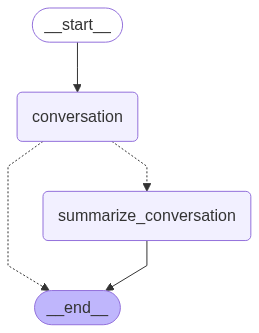

In [73]:
draw_graph(graph)


In [74]:
config = {"configurable": {"thread_id": "2"}}

# start the conversation

input_message = HumanMessage(content="Hi this is khaja")
output = graph.invoke({"messages": [input_message], "summary": None }, config=config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Hi Khaja, it's nice to meet you! How can I help you today?


In [75]:
input_message = HumanMessage(content="Whats my name")
output = graph.invoke({"messages": [input_message] }, config=config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Your name is Khaja.


In [76]:
input_message = HumanMessage(content="I like Game of Thrones")
output = graph.invoke({"messages": [input_message] }, config=config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

That's great! Game of Thrones is a very popular series. What do you like most about it? The characters, the plot, the dragons, the battles, the political intrigue? I'm curious to hear your thoughts!


In [77]:
graph.get_state(config).values.get('summary')


In [78]:
graph.get_state(config).values.get('messages')


[HumanMessage(content='Hi this is khaja', additional_kwargs={}, response_metadata={}, id='b127d766-0eab-4860-9447-32d120b40b75'),
 AIMessage(content="Hi Khaja, it's nice to meet you! How can I help you today?\n", additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 5, 'candidates_token_count': 20, 'total_token_count': 25, 'prompt_tokens_details': [{'modality': 1, 'token_count': 5}], 'candidates_tokens_details': [{'modality': 1, 'token_count': 20}], 'thoughts_token_count': 0, 'cached_content_token_count': 0, 'cache_tokens_details': []}, 'finish_reason': 'STOP', 'avg_logprobs': -0.037961751222610474, 'model_name': 'gemini-2.0-flash-lite-001'}, id='run--dd762cd3-6aaa-4fe2-b644-029d1daf51c2-0', usage_metadata={'input_tokens': 5, 'output_tokens': 20, 'total_tokens': 25}),
 HumanMessage(content='Whats my name', additional_kwargs={}, response_metadata={}, id='37278b75-313c-4d34-921b-cd93d2c2ecd7'),
 AIMessage(content='You

In [79]:
input_message = HumanMessage(content="I like Daenerys Targaryen. But didnt like her death. Isn't that brutal")
output = graph.invoke({"messages": [input_message]}, config=config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

Yes, many people, including myself, felt that Daenerys Targaryen's death was a very impactful and controversial moment in the series finale. It was certainly a brutal and tragic end for a character who had become a fan favorite for many. 

It's understandable to be disappointed by it, especially considering her journey and the ideals she presented earlier in the show. The sudden shift in her character and the way it was handled definitely sparked a lot of debate and strong opinions among viewers.

What specifically about her death bothered you the most? Was it the manner of her death, the timing, or the reasons behind it?


In [80]:
print(graph.get_state(config).values.get('summary'))


Here's a summary of our conversation:

*   **Introduction:** We greeted each other, and I confirmed Khaja's name.
*   **Shared Interest:** Khaja expressed enjoyment of the TV show "Game of Thrones."
*   **Discussion of Daenerys Targaryen:** Khaja stated they liked Daenerys, but disliked her death, finding it brutal.
*   **Reaction to Opinion:** I acknowledged the controversial nature of Daenerys' death and asked Khaja what specifically bothered them about it.



In [81]:
graph.get_state(config).values.get('messages')


[HumanMessage(content="I like Daenerys Targaryen. But didnt like her death. Isn't that brutal", additional_kwargs={}, response_metadata={}, id='4c4f113a-67e6-45e6-9bac-b11c23555333'),
 AIMessage(content="Yes, many people, including myself, felt that Daenerys Targaryen's death was a very impactful and controversial moment in the series finale. It was certainly a brutal and tragic end for a character who had become a fan favorite for many. \n\nIt's understandable to be disappointed by it, especially considering her journey and the ideals she presented earlier in the show. The sudden shift in her character and the way it was handled definitely sparked a lot of debate and strong opinions among viewers.\n\nWhat specifically about her death bothered you the most? Was it the manner of her death, the timing, or the reasons behind it?\n", additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 106, 'candidates_token_count': 12

In [82]:
input_message = HumanMessage(content="I felt betrayed")
output = graph.invoke({"messages": [input_message] }, config=config)
for m in output['messages'][-1:]:
    m.pretty_print()

================================== Ai Message ==================================

I can understand why you felt betrayed. That's a very common feeling among fans regarding Daenerys's death. Her actions in the final episodes, especially her turn towards destruction in King's Landing, were seen by many as a betrayal of the ideals she had initially championed, and of the trust viewers had placed in her.

To feel betrayed means you had expectations for her, you invested in her journey, and the ending didn't align with those expectations. It's a strong emotional response, and it's a valid one.

What about the betrayal felt most impactful to you? Was it the shift in her character's behavior, the fact that she didn't achieve the "right" ending, or something else entirely?


In [83]:
print(graph.get_state(config).values.get('summary'))


Here's a summary of our conversation:

*   **Introduction:** We greeted each other, and I confirmed Khaja's name.
*   **Shared Interest:** Khaja expressed enjoyment of the TV show "Game of Thrones."
*   **Discussion of Daenerys Targaryen:** Khaja stated they liked Daenerys, but disliked her death, finding it brutal.
*   **Reaction to Opinion:** I acknowledged the controversial nature of Daenerys' death and asked Khaja what specifically bothered them about it.



In [84]:
graph.get_state(config).values.get('messages')


[HumanMessage(content="I like Daenerys Targaryen. But didnt like her death. Isn't that brutal", additional_kwargs={}, response_metadata={}, id='4c4f113a-67e6-45e6-9bac-b11c23555333'),
 AIMessage(content="Yes, many people, including myself, felt that Daenerys Targaryen's death was a very impactful and controversial moment in the series finale. It was certainly a brutal and tragic end for a character who had become a fan favorite for many. \n\nIt's understandable to be disappointed by it, especially considering her journey and the ideals she presented earlier in the show. The sudden shift in her character and the way it was handled definitely sparked a lot of debate and strong opinions among viewers.\n\nWhat specifically about her death bothered you the most? Was it the manner of her death, the timing, or the reasons behind it?\n", additional_kwargs={}, response_metadata={'is_blocked': False, 'safety_ratings': [], 'usage_metadata': {'prompt_token_count': 106, 'candidates_token_count': 12